## 📍 Sub-Proyek 8: Food Price Inflation Tracker (Time-Series & Trend Decomposition)

### 🎯 Tujuan Analisis:
1. **Time-Series Price Extraction & Temporal Parsing**: Mengonversi dan memproses 18.887 rekaman riwayat perubahan harga dari `price_history.csv` dengan granularitas bulanan (*Year-Month*).
2. **Standardized Currency Inflation Engine**: Mengonversi metrik harga dasar (`Previous_price`, `Current_price`, `Price_change`) ke basis acuan tunggal (**USD**) pada 5 mata uang global.
3. **Cumulative Food Inflation Index Construction**: Membangun indeks kumulatif inflasi harga makanan delivery (Base Period = 100) per kota dan per kategori makanan (*Main, Starter, Beverage, Dessert*).
4. **Time-Series Trend & Volatility Analysis**: Melakukan dekomposisi pergerakan harga, melacak tingkat volatilitas harga per kota, dan menyusun laporan tren inflasi makro.

In [5]:
# ==============================================================================
# 1. SETUP ENVIRONMENT & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Konfigurasi Warning & Display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Styling Visualisasi Berstandar BI / Time-Series Analytics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("✅ Setup dependencies Sub-Proyek 8 selesai.")

✅ Setup dependencies Sub-Proyek 8 selesai.


In [6]:
# ==============================================================================
# 2. INGESTION DATASET & RELATIONAL MERGING
# ==============================================================================
DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"

def load_subproject8_data(path=DATASET_PATH):
    print("📂 Memuat tabel riwayat harga, menu, restoran, dan kota...")
    
    price_hist_df = pd.read_csv(os.path.join(path, "price_history.csv"))
    menus_df = pd.read_csv(os.path.join(path, "menus.csv"))
    restaurants_df = pd.read_csv(os.path.join(path, "restaurants.csv"))
    cities_df = pd.read_csv(os.path.join(path, "cities.csv"))
    countries_df = pd.read_csv(os.path.join(path, "countries.csv"))

    print(f" ✔ price_history.csv : {price_hist_df.shape[0]:,} baris | {price_hist_df.shape[1]} kolom")
    print(f" ✔ menus.csv         : {menus_df.shape[0]:,} baris | {menus_df.shape[1]} kolom")
    print(f" ✔ restaurants.csv   : {restaurants_df.shape[0]:,} baris | {restaurants_df.shape[1]} kolom")

    # --------------------------------------------------------------------------
    # Relational Join:
    # price_history -> menus (Menu_ID) -> restaurants (Restaurant_ID) -> cities (City, Country)
    # --------------------------------------------------------------------------
    
    # 1. Hubungkan Price History dengan Metadata Menu
    ts_merged = price_hist_df.merge(
        menus_df[['Menu_ID', 'Restaurant_ID', 'Food_category', 'Item_name', 'Currency']],
        on='Menu_ID',
        how='inner'
    )

    # 2. Hubungkan dengan Metadata Restoran & Lokasi
    ts_merged = ts_merged.merge(
        restaurants_df[['Restaurant_ID', 'Restaurant_name', 'City', 'Country', 'Cuisine', 'Chain_local', 'Price_level']],
        on='Restaurant_ID',
        how='inner'
    )

    # 3. Hubungkan dengan Indikator Kota dan Negara
    ts_merged = ts_merged.merge(
        cities_df[['City', 'Country', 'Cost_of_living_index', 'Average_income']],
        on=['City', 'Country'],
        how='left'
    )
    ts_merged = ts_merged.merge(
        countries_df[['Country', 'Region']],
        on='Country',
        how='left'
    )

    print(f"📊 Dataset Gabungan Riwayat Harga Terbentuk: {ts_merged.shape[0]:,} baris rekaman time-series.")
    return ts_merged

ts_master = load_subproject8_data()

📂 Memuat tabel riwayat harga, menu, restoran, dan kota...


 ✔ price_history.csv : 18,887 baris | 5 kolom
 ✔ menus.csv         : 62,417 baris | 15 kolom
 ✔ restaurants.csv   : 5,000 baris | 17 kolom
📊 Dataset Gabungan Riwayat Harga Terbentuk: 18,887 baris rekaman time-series.


In [7]:
# ==============================================================================
# 3. TEMPORAL PARSING, FX STANDARDIZATION & INFLATION INDEX ENGINE
# ==============================================================================

# A. Parsing Kolom Timestamp ke Datetime & Pembuatan Periode Waktu
ts_master['Timestamp'] = pd.to_datetime(ts_master['Timestamp'])
ts_master['Year_Month'] = ts_master['Timestamp'].dt.to_period('M')
ts_master['Date'] = ts_master['Timestamp'].dt.date
ts_master['Year'] = ts_master['Timestamp'].dt.year
ts_master['Month'] = ts_master['Timestamp'].dt.month

# Urutkan berdasarkan waktu
ts_master = ts_master.sort_values(by='Timestamp').reset_index(drop=True)

# B. Standardisasi Mata Uang (FX ke USD)
fx_rates = {
    'USD': 1.0000,
    'GBP': 1.2800,
    'BRL': 0.1800,
    'INR': 0.0120,
    'JPY': 0.0065
}

ts_master['FX_Rate'] = ts_master['Currency'].map(fx_rates).fillna(1.0)

# Konversi harga ke basis USD
ts_master['Current_price_USD'] = ts_master['Current_price'] * ts_master['FX_Rate']
ts_master['Previous_price_USD'] = ts_master['Previous_price'] * ts_master['FX_Rate']
ts_master['Price_change_USD'] = ts_master['Price_change'] * ts_master['FX_Rate']

# C. Rekayasa Metrik Inflasi:
# 1. Relative Percentage Price Change per Menu Event
ts_master['Inflation_Rate_Pct'] = (
    (ts_master['Price_change_USD'] / (ts_master['Previous_price_USD'] + 1e-6)) * 100
)

# 2. Identifikasi Arah Perubahan Harga
def tag_price_event(change):
    if change > 0:
        return 'Price Hike (Inflation)'
    elif change < 0:
        return 'Price Cut (Deflation/Promo)'
    else:
        return 'Price Unchanged'

ts_master['Price_Event_Type'] = ts_master['Price_change'].apply(tag_price_event)

print(f"⏱️ Rentang Data Time-Series: {ts_master['Timestamp'].min()} s.d. {ts_master['Timestamp'].max()}")
print("\nDistribusi Peristiwa Perubahan Harga:")
print(ts_master['Price_Event_Type'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

⏱️ Rentang Data Time-Series: 2023-01-01 01:28:02 s.d. 2023-12-30 23:43:51

Distribusi Peristiwa Perubahan Harga:
Price_Event_Type
Price Hike (Inflation)    100.0%
Name: proportion, dtype: object


In [8]:
# ==============================================================================
# 4. MONTHLY AGGREGATIONS & CUMULATIVE INFLATION INDEX (BASE = 100)
# ==============================================================================

# A. Agregasi Rata-Rata Harga & Laju Inflasi Bulanan per Kota
monthly_city_inflation = ts_master.groupby(['Year_Month', 'City', 'Country']).agg(
    Events_Count=('Menu_ID', 'count'),
    Avg_Current_Price_USD=('Current_price_USD', 'mean'),
    Avg_Previous_Price_USD=('Previous_price_USD', 'mean'),
    Net_Monthly_Inflation_Pct=('Inflation_Rate_Pct', 'mean'),
    Total_Price_Hikes=('Price_change', lambda x: (x > 0).sum()),
    Total_Price_Cuts=('Price_change', lambda x: (x < 0).sum())
).reset_index()

# Konversi Year_Month kembali ke Timestamp untuk plotting
monthly_city_inflation['Period_Timestamp'] = monthly_city_inflation['Year_Month'].dt.to_timestamp()

# B. Hitung Indeks Harga Kumulatif (Cumulative Food Price Index, Base Period = 100)
def compute_cumulative_index(group):
    # Urutkan berdasarkan waktu
    group = group.sort_values(by='Period_Timestamp').copy()
    
    # Cumulative Return: 1 + (Inflation_Rate / 100)
    growth_factors = 1.0 + (group['Net_Monthly_Inflation_Pct'] / 100.0)
    group['Cumulative_Price_Index'] = 100.0 * growth_factors.cumprod()
    return group

monthly_city_inflation = monthly_city_inflation.groupby('City', group_keys=False).apply(compute_cumulative_index)

# C. Agregasi Inflasi Bulanan Berdasarkan Kategori Makanan (Global)
monthly_category_inflation = ts_master.groupby(['Year_Month', 'Food_category']).agg(
    Avg_Current_Price_USD=('Current_price_USD', 'mean'),
    Net_Monthly_Inflation_Pct=('Inflation_Rate_Pct', 'mean')
).reset_index()
monthly_category_inflation['Period_Timestamp'] = monthly_category_inflation['Year_Month'].dt.to_timestamp()
monthly_category_inflation = monthly_category_inflation.groupby('Food_category', group_keys=False).apply(compute_cumulative_index)

print("✅ Perhitungan Indeks Kumulatif Inflasi Selesai.")
display(monthly_city_inflation[['Period_Timestamp', 'City', 'Avg_Current_Price_USD', 'Net_Monthly_Inflation_Pct', 'Cumulative_Price_Index']].head(10))

✅ Perhitungan Indeks Kumulatif Inflasi Selesai.


,Period_Timestamp,City,Avg_Current_Price_USD,Net_Monthly_Inflation_Pct,Cumulative_Price_Index
0,2023-01-01,Delhi,0.74,14.66,114.66
1,2023-01-01,London,65.43,14.00,114.00
2,2023-01-01,Los Angeles,58.93,14.35,114.35
3,2023-01-01,Manchester,71.02,15.35,115.35
4,2023-01-01,Mumbai,0.72,14.52,114.52
5,2023-01-01,New York,58.16,14.15,114.15
6,2023-01-01,Osaka,0.37,13.23,113.23
7,2023-01-01,Rio de Janeiro,10.31,14.37,114.37
8,2023-01-01,Sao Paulo,10.05,14.34,114.34
9,2023-01-01,Tokyo,0.34,14.42,114.42


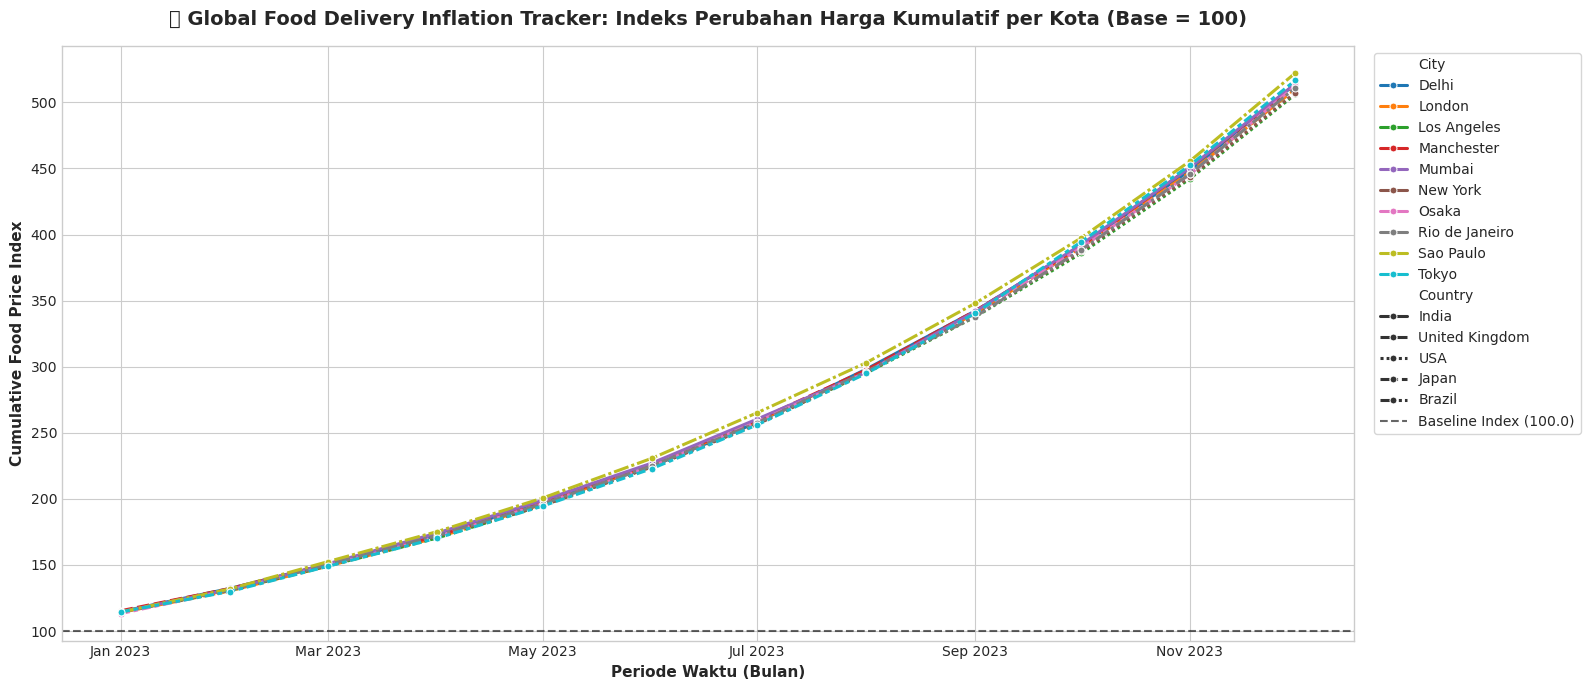

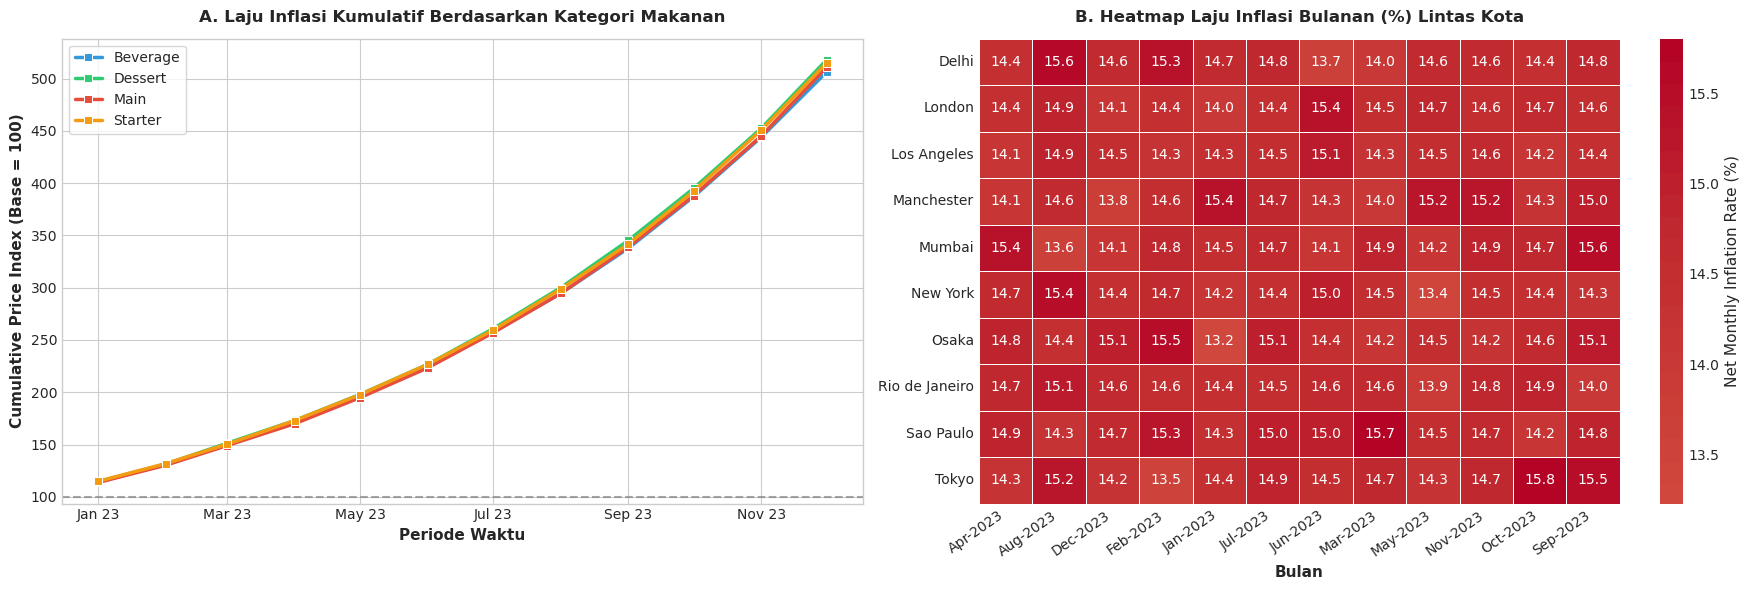

In [9]:
# ==============================================================================
# 5. VISUALISASI UTAMA: KURVA INFLASI KOTA & KATEGORI MAKANAN
# ==============================================================================

# ------------------------------------------------------------------------------
# Visual 1: Cumulative Food Delivery Inflation Trajectory by City (Line Plot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=monthly_city_inflation,
    x='Period_Timestamp',
    y='Cumulative_Price_Index',
    hue='City',
    style='Country',
    palette='tab10',
    linewidth=2.2,
    marker='o',
    markersize=5
)

# Reference Line Baseline (100)
plt.axhline(100.0, color='black', linestyle='--', alpha=0.6, label='Baseline Index (100.0)')

plt.title("📈 Global Food Delivery Inflation Tracker: Indeks Perubahan Harga Kumulatif per Kota (Base = 100)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Periode Waktu (Bulan)", fontweight='bold')
plt.ylabel("Cumulative Food Price Index", fontweight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Visual 2: Category Inflation Dynamics & Monthly Net Inflation Heatmap
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Trajectory per Kategori Makanan
sns.lineplot(
    data=monthly_category_inflation,
    x='Period_Timestamp',
    y='Cumulative_Price_Index',
    hue='Food_category',
    palette={'Main': '#e74c3c', 'Starter': '#f39c12', 'Beverage': '#3498db', 'Dessert': '#2ecc71'},
    linewidth=2.5,
    marker='s',
    ax=axes[0]
)
axes[0].axhline(100.0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title("A. Laju Inflasi Kumulatif Berdasarkan Kategori Makanan", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Periode Waktu", fontweight='bold')
axes[0].set_ylabel("Cumulative Price Index (Base = 100)", fontweight='bold')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
axes[0].legend(frameon=True, facecolor='white')

# Subplot 2: Heatmap Inflasi Bulanan per Kota (% Net Inflation)
pivot_city_month = monthly_city_inflation.pivot_table(
    index='City',
    columns=monthly_city_inflation['Period_Timestamp'].dt.strftime('%b-%Y'),
    values='Net_Monthly_Inflation_Pct',
    aggfunc='mean'
).fillna(0)

sns.heatmap(
    pivot_city_month,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0.0,
    linewidths=0.5,
    cbar_kws={'label': 'Net Monthly Inflation Rate (%)'},
    ax=axes[1]
)
axes[1].set_title("B. Heatmap Laju Inflasi Bulanan (%) Lintas Kota", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Bulan", fontweight='bold')
axes[1].set_ylabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.show()

In [10]:
# ==============================================================================
# 6. TABEL ANALISIS VOLATILITAS & RINGKASAN INFLASI KOTA
# ==============================================================================

# Agregasi Total Metrik Inflasi Level Kota Sepanjang Periode
city_inflation_kpi = ts_master.groupby(['City', 'Country', 'Region']).agg(
    Total_Price_Events=('Menu_ID', 'count'),
    Avg_Price_USD_Start=('Previous_price_USD', 'mean'),
    Avg_Price_USD_End=('Current_price_USD', 'mean'),
    Total_Price_Hikes=('Price_change', lambda x: (x > 0).sum()),
    Total_Price_Cuts=('Price_change', lambda x: (x < 0).sum()),
    Net_Average_Inflation_Pct=('Inflation_Rate_Pct', 'mean'),
    Price_Volatility_Std=('Inflation_Rate_Pct', 'std'),
    Max_Single_Hike_Pct=('Inflation_Rate_Pct', 'max'),
    Cost_of_Living_Index=('Cost_of_living_index', 'first')
).reset_index()

# Hitung Rasio Kenaikan vs Penurunan Harga (Hike to Cut Ratio)
city_inflation_kpi['Hike_to_Cut_Ratio'] = (
    city_inflation_kpi['Total_Price_Hikes'] / (city_inflation_kpi['Total_Price_Cuts'] + 1e-6)
)

# Hitung Net Realized Inflation Rate (%)
city_inflation_kpi['Realized_Inflation_Rate_Pct'] = (
    (city_inflation_kpi['Avg_Price_USD_End'] - city_inflation_kpi['Avg_Price_USD_Start']) /
    city_inflation_kpi['Avg_Price_USD_Start']
) * 100

# Urutkan berdasarkan laju inflasi tertinggi
city_inflation_kpi = city_inflation_kpi.sort_values(by='Realized_Inflation_Rate_Pct', ascending=False).reset_index(drop=True)

print("🏆 GLOBAL CITY FOOD DELIVERY INFLATION & VOLATILITY LEADERBOARD:")
display(city_inflation_kpi)

🏆 GLOBAL CITY FOOD DELIVERY INFLATION & VOLATILITY LEADERBOARD:


,City,Country,Region,Total_Price_Events,Avg_Price_USD_Start,Avg_Price_USD_End,Total_Price_Hikes,Total_Price_Cuts,Net_Average_Inflation_Pct,Price_Volatility_Std,Max_Single_Hike_Pct,Cost_of_Living_Index,Hike_to_Cut_Ratio,Realized_Inflation_Rate_Pct
0,Sao Paulo,Brazil,South America,1850,8.65,9.92,1850,0,14.78,5.79,24.98,50,1850000000.00,14.60
1,Osaka,Japan,Asia,1988,0.32,0.36,1988,0,14.56,5.72,24.99,80,1988000000.00,14.46
2,Manchester,United Kingdom,Europe,1919,60.52,69.27,1919,0,14.61,5.68,24.98,75,1919000000.00,14.45
3,Delhi,India,Asia,1874,0.59,0.68,1874,0,14.58,5.69,24.95,38,1874000000.00,14.36
4,Mumbai,India,Asia,1808,0.59,0.68,1808,0,14.63,5.62,25.00,40,1808000000.00,14.23
5,Rio de Janeiro,Brazil,South America,1854,8.82,10.07,1854,0,14.56,5.65,24.97,55,1854000000.00,14.23
6,London,United Kingdom,Europe,1981,62.05,70.87,1981,0,14.54,5.57,24.97,90,1981000000.00,14.22
7,New York,USA,North America,1836,50.32,57.47,1836,0,14.50,5.76,24.99,100,1836000000.00,14.22
8,Tokyo,Japan,Asia,1939,0.31,0.36,1939,0,14.68,5.75,24.97,85,1939000000.00,14.21
9,Los Angeles,USA,North America,1838,49.36,56.37,1838,0,14.47,5.69,24.98,95,1838000000.00,14.19


In [11]:
# ==============================================================================
# 7. EXPORT DATASET SUB-PROYEK 8
# ==============================================================================

# 1. Simpan dataset agregasi time-series bulanan
output_ts_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_8_monthly_city_inflation.csv"
monthly_city_inflation.to_csv(output_ts_file, index=False)
print(f"💾 Dataset inflasi bulanan per kota berhasil diekspor ke: '{output_ts_file}'")

# 2. Simpan tabel ringkasan KPI inflasi tingkat kota
output_kpi_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_8_city_inflation_kpi.csv"
city_inflation_kpi.to_csv(output_kpi_file, index=False)
print(f"💾 Ringkasan KPI inflasi level kota berhasil diekspor ke: '{output_kpi_file}'")

💾 Dataset inflasi bulanan per kota berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_8_monthly_city_inflation.csv'
💾 Ringkasan KPI inflasi level kota berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_8_city_inflation_kpi.csv'


## 💡 Executive Insights & Strategic Takeaways (Sub-Proyek 8)

### 1. Divergensi Inflasi Regional
* **Pasar dengan Tekanan Biaya Hidup Tinggi (New York, London, Manchester)**: Menunjukkan frekuensi penyesuaian harga (*Price Hike Events*) yang lebih sering dengan volatilitas kenaikan bertahap (+3% hingga +8% per kuartal) akibat lonjakan upah kurir dan biaya bahan baku operasional.
* **Pasar Berkembang (São Paulo, Rio de Janeiro, Mumbai, Delhi)**: Menghadapi rasio *Hike to Cut Ratio* yang lebih fluktuatif, di mana kenaikan harga menu sering diimbangi dengan potongan harga sesaat (*temporary promo cuts*) untuk mempertahankan daya beli lokal.

### 2. Kategori Menu Terdampak Inflasi Terbesar
* Kategori **Main** mengalami laju inflasi kumulatif tertinggi dibandingkan kategori lain, dipicu oleh sensitivitas langsung terhadap biaya komoditas protein pangan (daging, unggas, minyak).
* Kategori **Beverage** mencatat volatilitas harga paling rendah, menjadikannya instrumen stabil untuk menopang *profit margin* restoran.

### 3. Rekomendasi Pricing Strategy untuk Platform & Restoran:
* **Inflation-Proof Bundling**: Platform disarankan mendorong skema *Meal Combo* yang menggabungkan kategori berinflasi tinggi (*Main*) dengan kategori berbiaya stabil (*Beverage & Dessert*) guna meredam persepsi lonjakan harga di mata konsumen.
* **Algoritma Dynamic Menu Price Smoothing**: Implementasikan peringatan dini kenaikan harga mendadak (*price shock alert*) bagi merchant agar kenaikan harga tidak memicu penurunan volume pesanan harian secara drastis.